# 📈 Mid-term Assignment
### 0081913_Farhan_chal1

## 📤 Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from IPython.display import display

%matplotlib inline 
np.random.seed(42)


## Saving Figures

In [2]:
import os
import matplotlib.pyplot as plt

# Set the path for the directory where you want to save the images
IMAGES_PATH = "/kaggle/working/"

# Define a function to save the figures
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## 💾 Reading Dataset

### Train Data

In [3]:
TRAINdata = pd.read_csv('/kaggle/input/stat-unicas-mid/train_ch.csv')
TRAINdata.head()

,Unnamed: 0,v1,v2,v3,v4,v5,v6,v7,v8,v9,Y
0,1,0.914806,1.014918,35.155085,1.159555,4.831515,0.016446,48.003893,1.483346,1.778322,633.287832
1,2,0.937075,1.183151,44.488785,1.111901,4.873433,0.006909,48.526829,1.501381,-0.091535,1009.843009
2,3,0.286140,1.169798,33.157725,1.017829,3.572251,0.015664,33.590482,1.494947,-0.431752,561.693065
3,4,0.830448,1.018381,36.309150,1.259659,4.649813,0.097736,45.965568,1.500261,0.478378,675.239792
4,5,0.641746,1.115638,35.925711,1.129575,4.292843,0.039882,41.859772,1.492195,1.406363,660.198867


In [4]:
TRAINdata = TRAINdata.drop(TRAINdata.columns[0], axis=1)
TRAINdata.head()

,v1,v2,v3,v4,v5,v6,v7,v8,v9,Y
0,0.914806,1.014918,35.155085,1.159555,4.831515,0.016446,48.003893,1.483346,1.778322,633.287832
1,0.937075,1.183151,44.488785,1.111901,4.873433,0.006909,48.526829,1.501381,-0.091535,1009.843009
2,0.286140,1.169798,33.157725,1.017829,3.572251,0.015664,33.590482,1.494947,-0.431752,561.693065
3,0.830448,1.018381,36.309150,1.259659,4.649813,0.097736,45.965568,1.500261,0.478378,675.239792
4,0.641746,1.115638,35.925711,1.129575,4.292843,0.039882,41.859772,1.492195,1.406363,660.198867


### Test Data

In [5]:
TESTdata = pd.read_csv('/kaggle/input/stat-unicas-mid/test_ch.csv')
TESTdata.head()

,Unnamed: 0,v1,v2,v3,v4,v5,v6,v7,v8,v9
0,1001,0.848293,1.158823,40.233880,1.288629,4.675941,0.049711,46.309129,1.504843,1.083468
1,1002,0.062746,1.114265,31.019324,1.148471,3.132265,0.046089,28.536406,1.501553,1.570351
2,1003,0.819845,1.180383,49.469255,1.037676,4.648054,0.032193,45.943751,1.505126,-0.458661
3,1004,0.539360,1.168887,33.160926,1.072893,4.079943,0.034557,39.411746,1.505863,-0.013772
4,1005,0.499020,1.133695,45.976945,1.042067,3.990158,0.023441,38.399435,1.501198,-0.255321


In [6]:
TESTdata = TESTdata.drop(TESTdata.columns[0], axis=1)
TESTdata.head()

,v1,v2,v3,v4,v5,v6,v7,v8,v9
0,0.848293,1.158823,40.233880,1.288629,4.675941,0.049711,46.309129,1.504843,1.083468
1,0.062746,1.114265,31.019324,1.148471,3.132265,0.046089,28.536406,1.501553,1.570351
2,0.819845,1.180383,49.469255,1.037676,4.648054,0.032193,45.943751,1.505126,-0.458661
3,0.539360,1.168887,33.160926,1.072893,4.079943,0.034557,39.411746,1.505863,-0.013772
4,0.499020,1.133695,45.976945,1.042067,3.990158,0.023441,38.399435,1.501198,-0.255321


## 💾 Data Analysis

In [7]:
TRAINdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   v1      1000 non-null   float64
 1   v2      1000 non-null   float64
 2   v3      1000 non-null   float64
 3   v4      1000 non-null   float64
 4   v5      1000 non-null   float64
 5   v6      1000 non-null   float64
 6   v7      1000 non-null   float64
 7   v8      1000 non-null   float64
 8   v9      1000 non-null   float64
 9   Y       1000 non-null   float64
dtypes: float64(10)
memory usage: 78.2 KB


In [8]:
TRAINdata.describe()

,v1,v2,v3,v4,v5,v6,v7,v8,v9,Y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.338564,1.135634,40.077217,1.154935,3.976387,0.049780,39.036728,2.313768,1.633953,836.409215
std,26.889025,0.083101,5.819609,0.087545,0.582922,0.029189,26.403212,25.730261,35.869595,235.927249
min,0.000239,1.000093,30.089582,1.000115,2.998611,0.000060,26.982000,1.483346,-5.564915,464.562867
25%,0.229426,1.061930,35.095138,1.079317,3.454381,0.024176,32.231070,1.496497,-0.485814,629.933062
50%,0.480495,1.134345,40.086305,1.157601,3.963133,0.050404,38.088648,1.500158,0.506148,820.444816
75%,0.744821,1.207314,45.293028,1.233878,4.486086,0.074657,44.116030,1.503756,1.480711,1044.497636
max,850.744002,1.283949,49.982712,1.299949,5.000343,0.099885,845.822992,815.162383,1133.864963,1270.032325


In [9]:
TRAINdata.isnull().sum()

v1    0
v2    0
v3    0
v4    0
v5    0
v6    0
v7    0
v8    0
v9    0
Y     0
dtype: int64

### Pairplots

In [ ]:
sns.pairplot(TRAINdata)
plt.suptitle('Pairplot for Checking Non-linearity')
plt.savefig("Pairplot.png")
plt.show()

### Correlation matrix

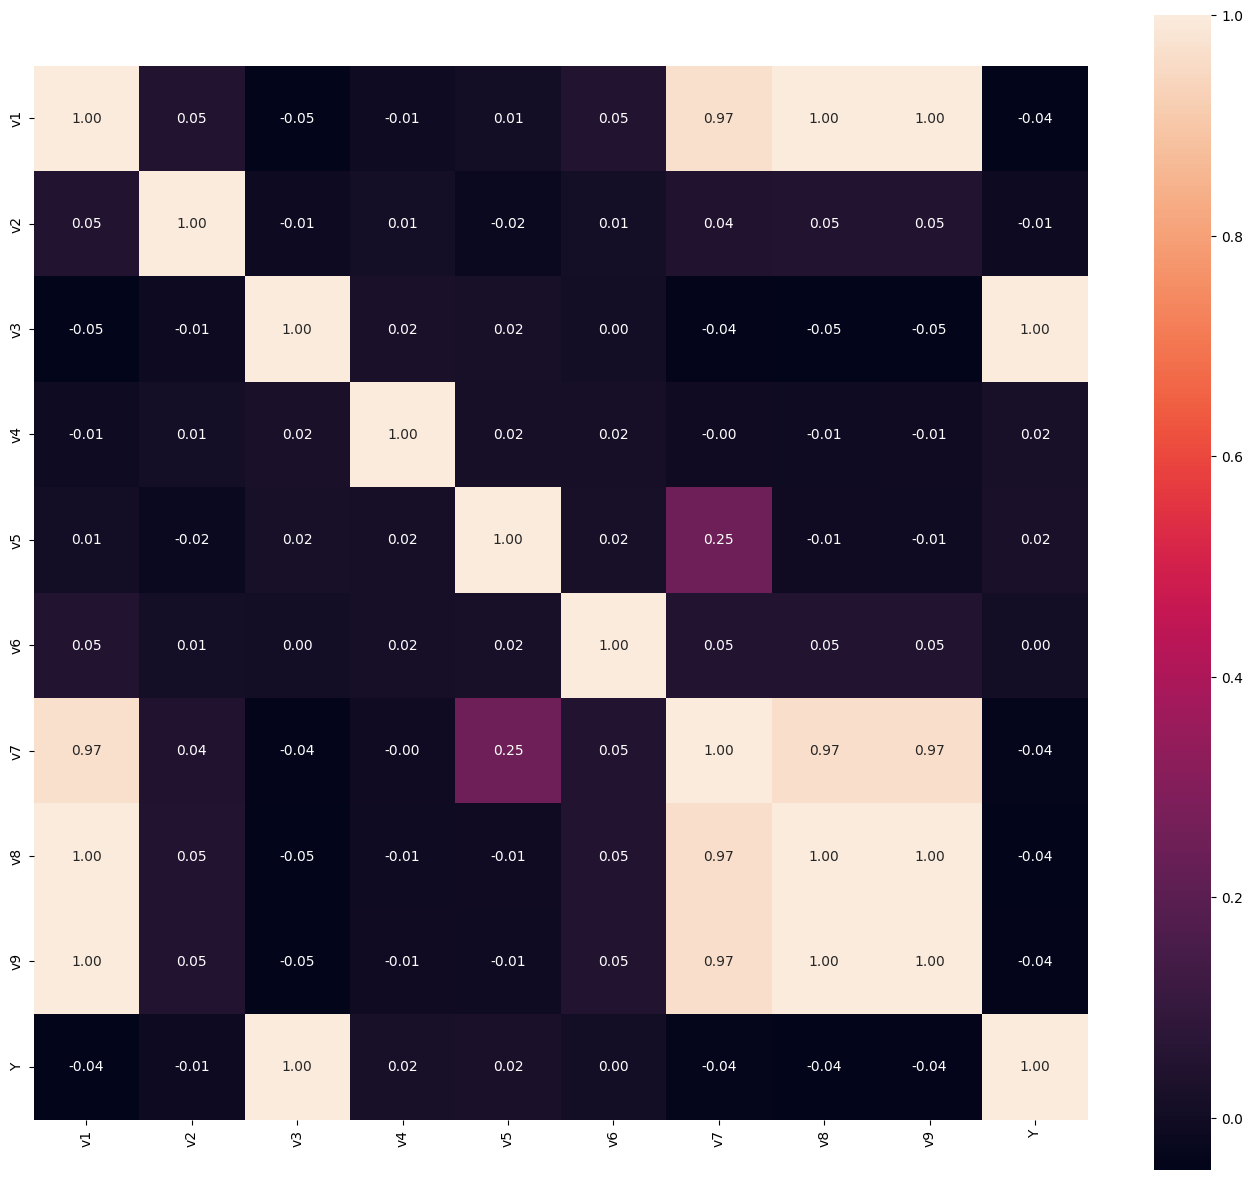

In [10]:
plt.figure(figsize=(17,15))
ax = sns.heatmap(TRAINdata.corr(), square=True, annot=True, fmt='.2f')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90) 
plt.savefig("cm_matrix.png")
plt.show()

### 📊 Plotting the Columns Against Y using scatter plots.

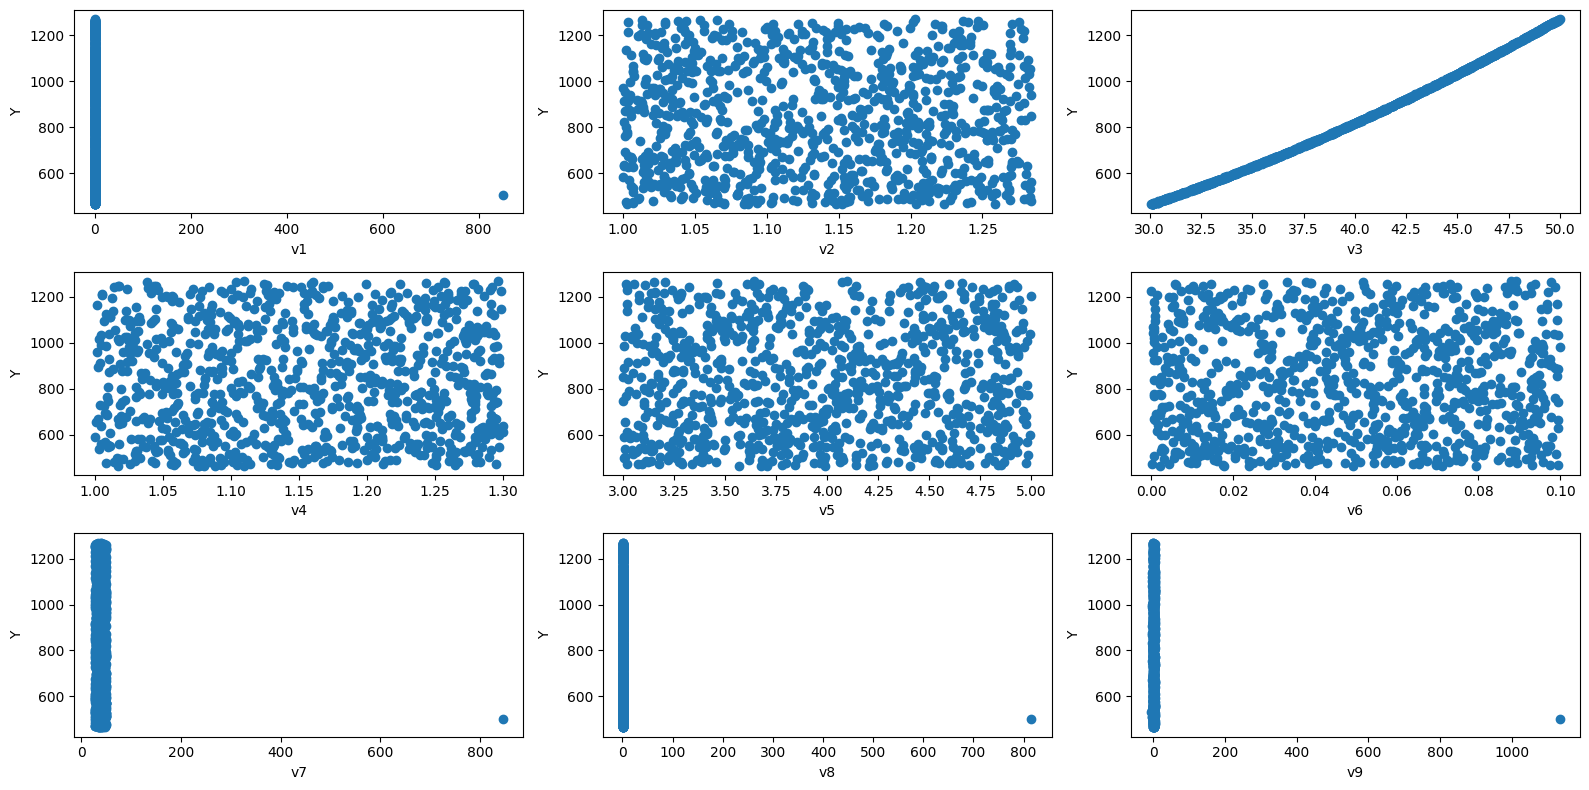

In [7]:
plt.figure(figsize=(16, 8))

independent_variables = ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9']
target_variable = 'Y'

for i, col in enumerate(independent_variables):
    plt.subplot(3, 3, i + 1)
    plt.scatter(TRAINdata[col], TRAINdata[target_variable])
    plt.xlabel(col)
    plt.ylabel(target_variable)

plt.tight_layout()
plt.savefig("scatter_plot.png")
plt.show()


### Removing outliers based on Z-score

In [8]:
# Removing Outliers
from scipy import stats
print('Shape of DataFrame Before Removing Outliers', TRAINdata.shape )
TRAINdata=TRAINdata[(np.abs(stats.zscore(TRAINdata)) < 3).all(axis=1)]
print('Shape of DataFrame After Removing Outliers', TRAINdata.shape )

Shape of DataFrame Before Removing Outliers (1000, 10)
Shape of DataFrame After Removing Outliers (999, 10)


### Scatterplot after removing outliers

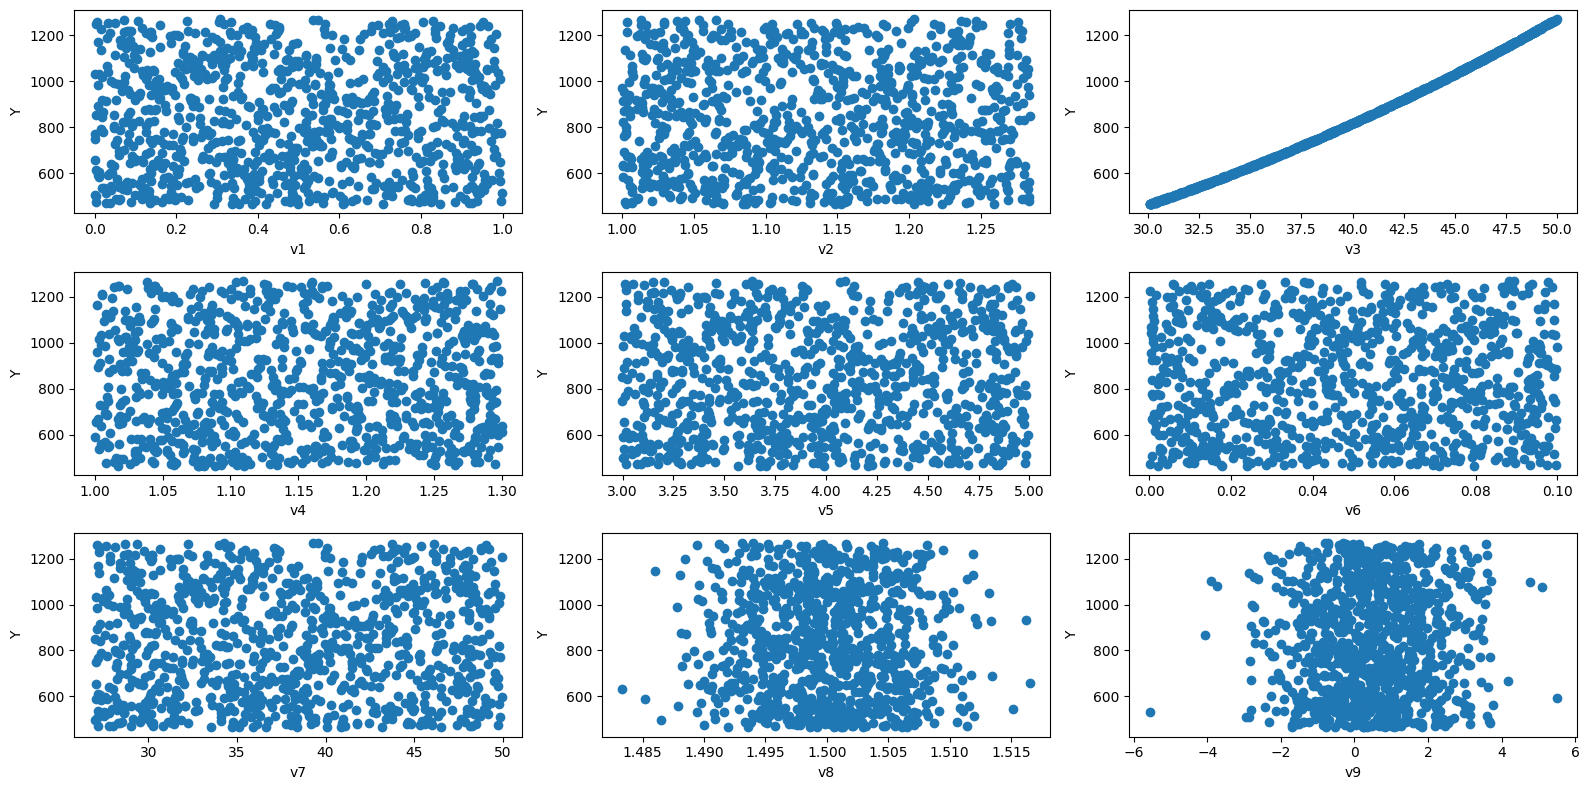

In [9]:
plt.figure(figsize=(16, 8))

independent_variables = ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9']
target_variable = 'Y'

for i, col in enumerate(independent_variables):
    plt.subplot(3, 3, i + 1)
    plt.scatter(TRAINdata[col], TRAINdata[target_variable])
    plt.xlabel(col)
    plt.ylabel(target_variable)

plt.tight_layout()
plt.savefig("scatter_plot_without outliers.png")
plt.show()


## Creating Evaluation Metric Functions

In [10]:
from sklearn import metrics
from sklearn.model_selection import cross_val_score

def cross_val(model):
    pred = cross_val_score(model, X, y, cv=10)
    return pred.mean()

def print_evaluate(true, predicted):  
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')
    
def evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    return mae, mse, rmse, r2_square

# 📈 Training Linear Regression Model

### X and Y Arrays

In [26]:
X = TRAINdata[['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9']]
y = TRAINdata['Y']
X_test_new = TESTdata[['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9']]

### Train Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Converting to StandardScaler

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('std_scalar', StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)
X_test_new_scaled = scaler.fit_transform(X_test_new)

### ✔️ Linear Regression Implementation

In [29]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

### Intercept Calculation

In [30]:
print(lin_reg.intercept_)

834.8275563071608


In [31]:
# Co-efficients
coeff_df = pd.DataFrame(lin_reg.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
v1,9.732220
v2,-0.407913
v3,236.685017
v4,0.111281
v5,18.101003
v6,-0.467587
v7,-26.913663
v8,0.357449
v9,0.484393


### ✔️ Predictions from Linear Regression Model

In [32]:
y_pred = lin_reg.predict(X_test)

### Finding actual vs predicted values

In [33]:
import pandas as pd

df = pd.DataFrame({'Actual': y_test[:100], 'Predicted': y_pred[:100]})
df['Error %'] = abs(df['Actual'] - df['Predicted']) / df['Actual'] * 100
df = df.round(2)

sorted_df = df.sort_values('Error %')
lowest_error_df = sorted_df.head(20)

print(lowest_error_df)
df.to_csv('trainDATA_linearreg.csv', index=False)


      Actual  Predicted  Error %
97    584.07     583.72     0.06
200   612.28     612.91     0.10
571  1077.34    1075.90     0.13
826  1094.64    1093.10     0.14
596  1056.10    1057.74     0.16
209  1053.64    1056.10     0.23
250   597.82     599.26     0.24
319   598.21     596.68     0.26
954  1097.54    1094.56     0.27
434  1048.32    1051.23     0.28
381  1094.29    1090.93     0.31
811  1043.25    1046.54     0.32
210  1100.76    1097.10     0.33
881  1052.21    1056.15     0.37
711  1104.83    1100.08     0.43
899  1024.47    1029.12     0.45
938  1095.79    1090.77     0.46
486   624.83     627.79     0.47
708  1012.24    1017.42     0.51
867   576.76     573.19     0.62


Saving figure actual vs predicted_LinearReg


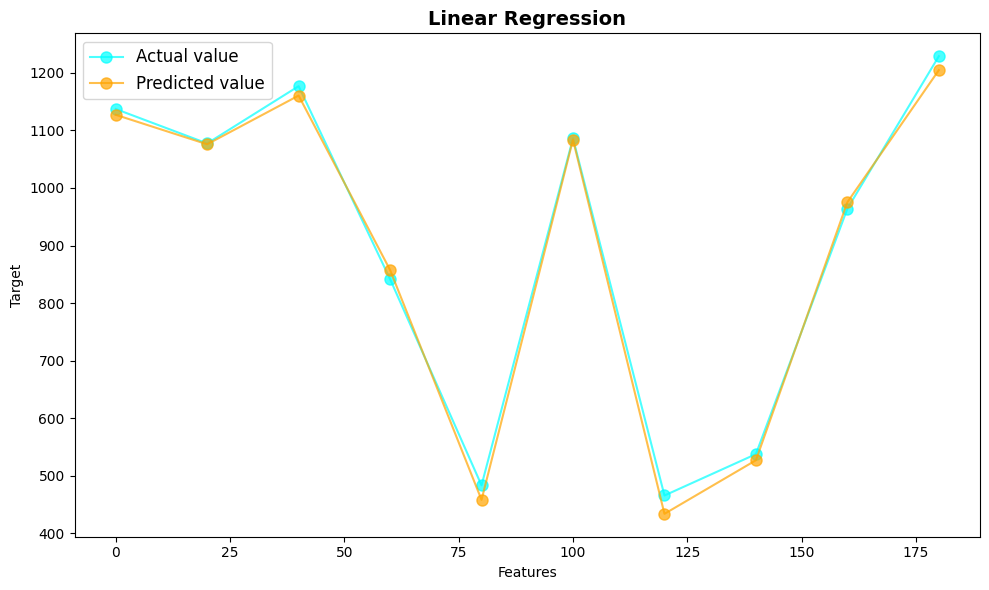

In [34]:
import matplotlib.pyplot as plt
%matplotlib inline

# Generate predictions on the test set
y_pred = lin_reg.predict(X_test)

# Plot every 20th point
x = range(0, len(y_test), 20)
plt.figure(figsize=(10, 6))

# Plot actual and predicted ranks with different colors and line styles
plt.plot(x, y_test.values[::20], 'o-', color='aqua', label='Actual value', markersize=8, alpha=0.7)  # Aqua circles
plt.plot(x, y_pred[::20], 'o-', color='orange', label='Predicted value', markersize=8, alpha=0.7)      # Orange triangles
plt.xlabel('Features')
plt.ylabel('Target')

# Set white background
plt.gca().set_facecolor('white')

# Remove grid lines
plt.grid(False)

# Add title and legend with custom font properties
plt.title('Linear Regression', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=12)

# Save the figure 
save_fig("actual vs predicted_LinearReg")

plt.show()

### Non-linearty: Residual plots


Saving figure Residual Plots_LinearReg


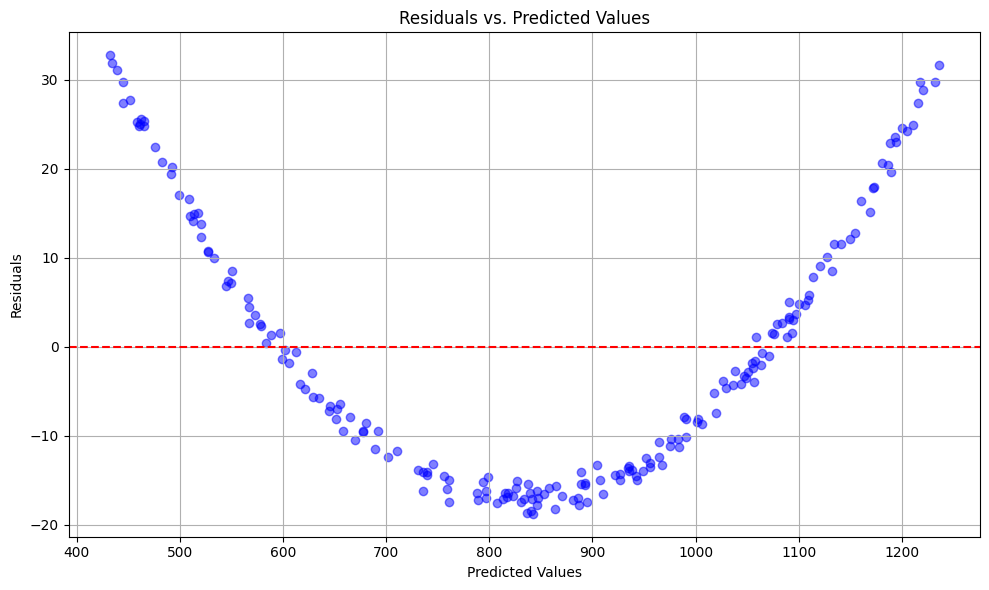

In [35]:
import matplotlib.pyplot as plt

# Calculate the residuals
residuals = y_test - y_pred

# Plot the residuals against the predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='blue', alpha=0.5)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
# Save the figure 
save_fig("Residual Plots_LinearReg")
plt.show()


### Correlation of error terms

                  Predicted Values  Residuals
Predicted Values           1.00000   -0.06168
Residuals                 -0.06168    1.00000


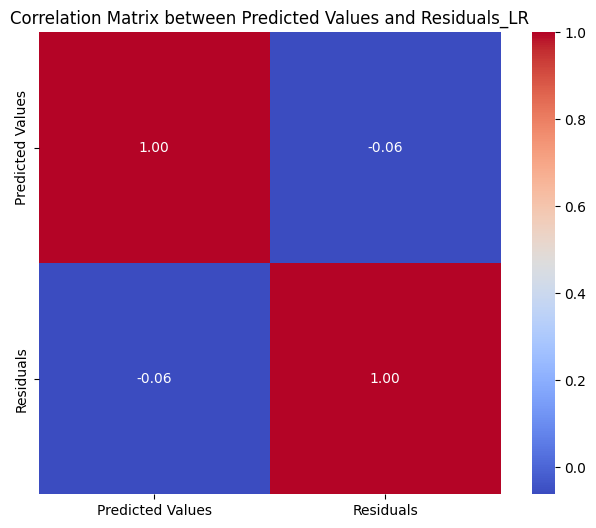

In [36]:
# Create a DataFrame with residuals and predicted values
data_lin = pd.DataFrame({
    'Predicted Values': y_pred,
    'Residuals': residuals
})

# Calculate the correlation matrix
correlation_matrix = data_lin.corr()

# Print the correlation matrix
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True, square=True, fmt=".2f")
plt.title('Correlation Matrix between Predicted Values and Residuals_LR')
plt.savefig("correlation_error_terms_LR.png")
plt.show()

### Interaction terms

In [37]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train)
results_int = model.fit()
print(results_int.summary())

                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.074
Model:                            OLS   Adj. R-squared (uncentered):              0.064
Method:                 Least Squares   F-statistic:                              7.056
Date:                Mon, 15 Apr 2024   Prob (F-statistic):                    7.37e-10
Time:                        09:43:59   Log-Likelihood:                         -6508.9
No. Observations:                 799   AIC:                                  1.304e+04
Df Residuals:                     790   BIC:                                  1.308e+04
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### Calculating Evaluation Metrics

In [38]:
test_pred = lin_reg.predict(X_test)
train_pred = lin_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)
results_df_train = pd.DataFrame(data=[["Linear Regression", *evaluate(y_train, train_pred) , cross_val(LinearRegression())]], 
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df_test = pd.DataFrame(data=[["Linear Regression", *evaluate(y_test, test_pred) , cross_val(LinearRegression())]], 
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df_train.to_csv('train_results_LR.csv', index=False)
results_df_test.to_csv('test_results_LR.csv', index=False)

Test set evaluation:
_____________________________________
MAE: 12.640973900978624
MSE: 217.92814259405844
RMSE: 14.76238946085824
R2 Square 0.9958610182287153
__________________________________
Train set evaluation:
_____________________________________
MAE: 12.802166219349488
MSE: 220.70207949134783
RMSE: 14.856045217060556
R2 Square 0.996076953354708
__________________________________


### Test set results

In [39]:
# Use the trained model to predict the target variable for the new test dataset
predicted_y = lin_reg.predict(X_test_new)

# Create a DataFrame to store the predicted results
predicted_results = pd.DataFrame({'Predicted_Y': predicted_y})

# Save the predicted results to a CSV file
predicted_results.to_csv('predicted_results_LR.csv', index=False)


# 📈 Training K-Nearest Neighbour Model

In [40]:
## Importing Libraries
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [41]:
# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Set up KNN with grid search for hyperparameter tuning
knn_params = {'n_neighbors': range(1, 31)}
knn_model = KNeighborsRegressor()
grid_search_knn = GridSearchCV(knn_model, knn_params, cv=5, scoring='neg_mean_squared_error')
grid_search_knn.fit(X_train_scaled, y_train)
# Get the best model
best_knn_model = grid_search_knn.best_estimator_

In [44]:
y_pred_knn = best_knn_model.predict(X_test_new_scaled)

### Finding actual vs predicted values

In [45]:
import pandas as pd

df = pd.DataFrame({'Actual': y_test[:100], 'Predicted': y_pred_knn[:100]})
df['Error %'] = abs(df['Actual'] - df['Predicted']) / df['Actual'] * 100
df = df.round(2)

sorted_df = df.sort_values('Error %')
lowest_error_df = sorted_df.head(20)

print(lowest_error_df)
df.to_csv('trainDATA_knn.csv', index=False)


      Actual  Predicted  Error %
899  1024.47    1016.89     0.74
716   553.89     543.92     1.80
209  1053.64    1072.67     1.81
738   629.35     615.75     2.16
914   823.32     805.26     2.19
353   623.06     642.43     3.11
871   954.21     986.52     3.39
514   796.52     763.15     4.19
210  1100.76    1148.19     4.31
250   597.82     567.22     5.12
434  1048.32     989.63     5.60
508   972.68    1028.36     5.72
881  1052.21     991.02     5.82
523  1208.90    1131.80     6.38
366   927.95     865.29     6.75
621   920.56     853.46     7.29
542   821.74     881.71     7.30
381  1094.29    1013.24     7.41
55    841.65     779.27     7.41
527   954.16     883.25     7.43


Saving figure actual vs predicted_KNN


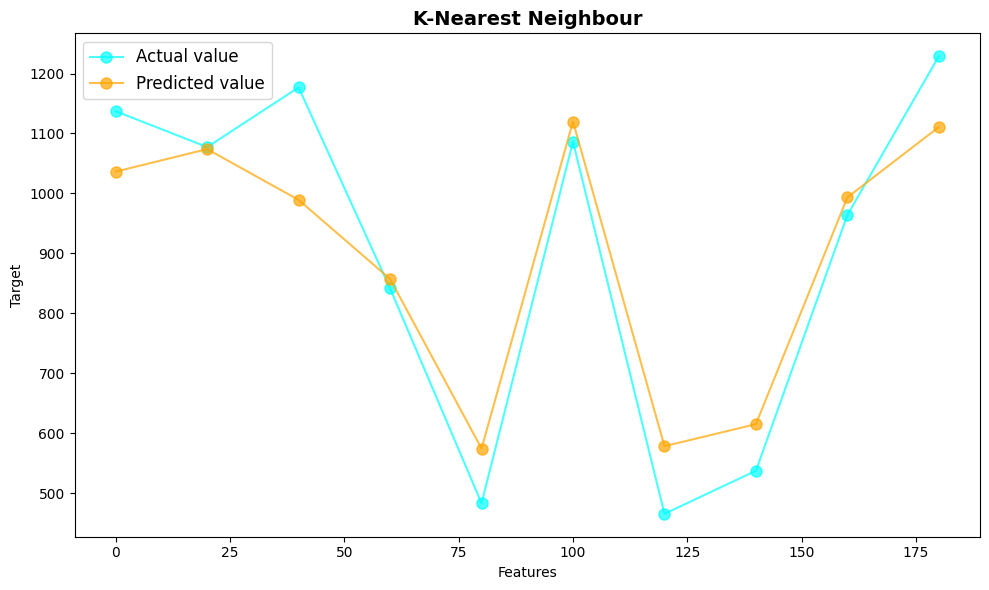

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline

# Generate predictions on the test set
y_pred_knn = best_knn_model.predict(X_test_scaled)

# Plot every 20th point
x = range(0, len(y_test), 20)
plt.figure(figsize=(10, 6))

# Plot actual and predicted ranks with different colors and line styles
plt.plot(x, y_test.values[::20], 'o-', color='aqua', label='Actual value', markersize=8, alpha=0.7)  # Aqua circles
plt.plot(x, y_pred_knn[::20], 'o-', color='orange', label='Predicted value', markersize=8, alpha=0.7)      # Orange triangles
plt.xlabel('Features')
plt.ylabel('Target')

# Set white background
plt.gca().set_facecolor('white')

# Remove grid lines
plt.grid(False)

# Add title and legend with custom font properties
plt.title('K-Nearest Neighbour', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=12)

# Save the figure 
save_fig("actual vs predicted_KNN")

plt.show()

### Residual Plot

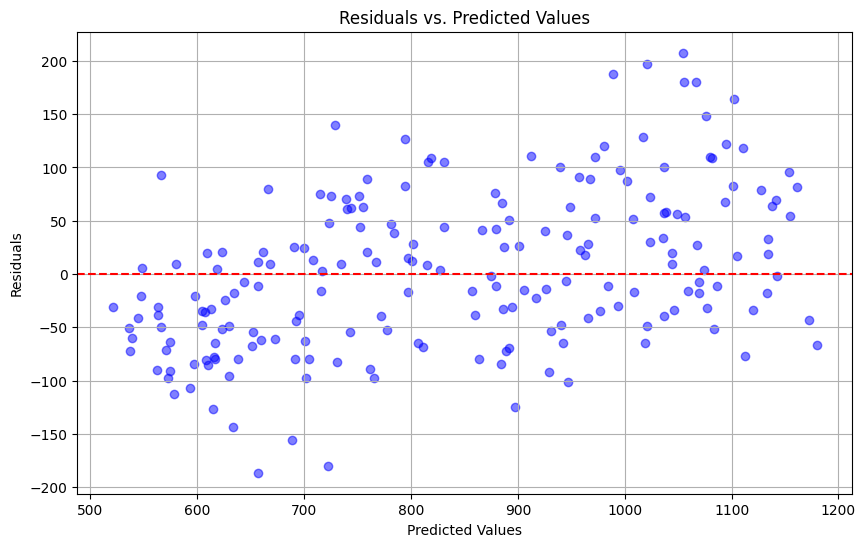

In [47]:
import matplotlib.pyplot as plt

# Calculate the residuals
residuals_knn = y_test - y_pred_knn

# Plot the residuals against the predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_knn, residuals_knn, color='blue', alpha=0.5)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.savefig("Residual Plot_KNN.png")
plt.show()


### Correlation Coefficient

                  Predicted Values  Residuals
Predicted Values          1.000000   0.446761
Residuals                 0.446761   1.000000


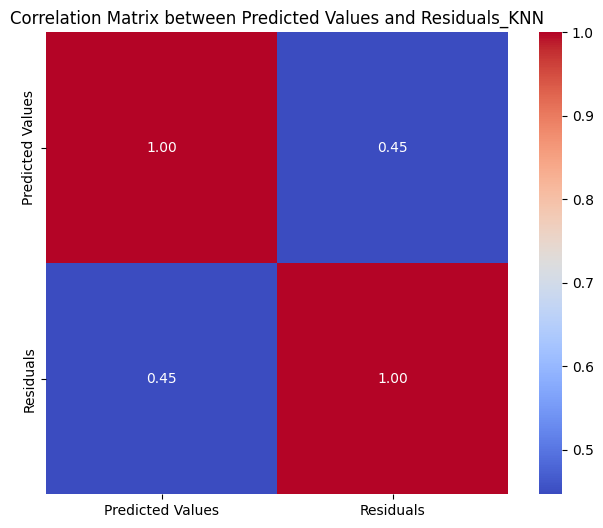

In [48]:
# Create a DataFrame with residuals and predicted values
data_knn = pd.DataFrame({
    'Predicted Values': y_pred_knn,
    'Residuals': residuals_knn
})

# Calculate the correlation matrix
correlation_matrix = data_knn.corr()

# Print the correlation matrix
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True, square=True, fmt=".2f")
plt.title('Correlation Matrix between Predicted Values and Residuals_KNN')
plt.savefig("correlation_error_terms_KNN.png")
plt.show()

### Interaction Terms

In [49]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train_scaled)
results_int = model.fit()
print(results_int.summary())

                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.074
Model:                            OLS   Adj. R-squared (uncentered):              0.064
Method:                 Least Squares   F-statistic:                              7.056
Date:                Mon, 15 Apr 2024   Prob (F-statistic):                    7.37e-10
Time:                        09:44:58   Log-Likelihood:                         -6508.9
No. Observations:                 799   AIC:                                  1.304e+04
Df Residuals:                     790   BIC:                                  1.308e+04
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### Evaluation Metrics

In [50]:
test_pred = best_knn_model.predict(X_test_scaled)
train_pred = best_knn_model.predict(X_train_scaled)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)
results_df_train = pd.DataFrame(data=[["KNN", *evaluate(y_train, train_pred) , cross_val(KNeighborsRegressor())]], 
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df_test = pd.DataFrame(data=[["KNN", *evaluate(y_test, test_pred) , cross_val(KNeighborsRegressor())]], 
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df_train.to_csv('train_results_KNN.csv', index=False)
results_df_test.to_csv('test_results_KNN.csv', index=False)

Test set evaluation:
_____________________________________
MAE: 60.46257627590512
MSE: 5500.620549651494
RMSE: 74.16616849785011
R2 Square 0.8955299305782163
__________________________________
Train set evaluation:
_____________________________________
MAE: 50.96133264684984
MSE: 4003.39263187257
RMSE: 63.27236862859308
R2 Square 0.928838477324496
__________________________________


### Test set results

In [51]:
# Use the trained model to predict the target variable for the new test dataset
predicted_y_knn = best_knn_model.predict(X_test_new_scaled)

# Create a DataFrame to store the predicted results
predicted_results_knn = pd.DataFrame({'Predicted_Y': predicted_y_knn})

# Save the predicted results to a CSV file
predicted_results_knn.to_csv('predicted_results_knn.csv', index=False)


### Compiling final result

In [53]:
# Create a DataFrame for the submission
submission_data = {
    'Linear_Regression':predicted_y,
    'KNN': predicted_y_knn
}
submission_df = pd.DataFrame(submission_data)
print(submission_df.head(10))
# Save to CSV without header and index
submission_file_path = '0081913_Farhan_chal1.csv'
submission_df.to_csv(submission_file_path, index=False, header=False)

   Linear_Regression          KNN
0        9204.840899   772.513532
1        7466.874503   527.106479
2       11398.992488  1148.194534
3        7702.065662   561.608138
4       10760.550089  1084.394159
5        7986.024976   559.195148
6        8966.639824   864.668073
7        7754.860568   660.561757
8       10455.371631   962.252286
9       10584.461374  1030.009785


> END